<a href="https://colab.research.google.com/github/jdrubianog-crypto/ods-streamlit-app/blob/main/Clasificacion_Sentimientos_IMDb_Recurrente_Optimizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Sentimientos de Reseñas IMDb con LSTM optimizada

Este notebook implementa un pipeline más liviano y rápido para Google Colab. Conserva los elementos requeridos del proyecto: descarga desde KaggleHub, limpieza textual, tokenización, embeddings entrenables, arquitectura recurrente LSTM/GRU, entrenamiento por 10 épocas, evaluación con accuracy, precision, recall y F1-score, visualización del modelo con `plot_model`, tabla de embeddings y reducción UMAP 3D coloreada según la clasificación positiva o negativa de reseñas.

Diego Fernando Becerra Zambrano

Andrea Johanna Tellez Acosta

Juan David Rubiano Granada

Profesor: Luis Felipe Giraldo Trujillo

Técnicas de Deep Learning

## 1. Instalación de librerías

Se instalan las dependencias necesarias para descargar el dataset, entrenar el modelo, visualizar la arquitectura y construir la proyección 3D de embeddings.

In [ ]:
# Instalación de librerías necesarias para Google Colab
!pip install kagglehub umap-learn plotly pydot graphviz -q
!apt-get install graphviz -y > /dev/null

## 2. Importación de librerías

Se importan herramientas para procesamiento de datos, modelado neuronal, evaluación y visualización.

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import umap
import plotly.express as px

from IPython.display import Image, display

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 3. Reproducibilidad y configuración de ejecución

Se fija una semilla para estabilizar el experimento. También se intenta activar crecimiento dinámico de memoria en GPU, lo cual evita algunos errores comunes en Colab.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuración ligera para GPU en Colab, si está disponible
try:
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada: {gpus}")
    else:
        print("No se detectó GPU. El notebook funcionará, pero puede tardar más.")
except Exception as e:
    print("No fue posible configurar la GPU:", e)

GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Descarga del dataset desde KaggleHub

El dataset se descarga directamente desde KaggleHub. Esta forma facilita la reproducción del notebook en Google Colab.

In [ ]:
path = kagglehub.dataset_download("yasserh/imdb-movie-ratings-sentiment-analysis")

print("Ruta del dataset:", path)
print("Archivos encontrados:")
print(os.listdir(path))

Using Colab cache for faster access to the 'imdb-movie-ratings-sentiment-analysis' dataset.
Ruta del dataset: /kaggle/input/imdb-movie-ratings-sentiment-analysis
Archivos encontrados:
['movie.csv']


## 5. Carga automática del archivo CSV

Se localiza el archivo `.csv` descargado y se carga como DataFrame.

In [ ]:
csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Archivos CSV detectados:")
for file in csv_files:
    print(file)

if len(csv_files) == 0:
    raise FileNotFoundError("No se encontró ningún archivo CSV en la carpeta descargada.")

df = pd.read_csv(csv_files[0])

print("Dimensiones del dataset:", df.shape)
df.head()

Archivos CSV detectados:
/kaggle/input/imdb-movie-ratings-sentiment-analysis/movie.csv
Dimensiones del dataset: (40000, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


## 6. Revisión inicial del dataset

Se inspeccionan columnas, valores faltantes y distribución de clases.

In [ ]:
print("Columnas disponibles:")
print(df.columns)

print("\nInformación general:")
print(df.info())

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDistribución de etiquetas:")
print(df["label"].value_counts())

Columnas disponibles:
Index(['text', 'label'], dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB
None

Valores faltantes:
text     0
label    0
dtype: int64

Distribución de etiquetas:
label
0    20019
1    19981
Name: count, dtype: int64


## 7. Limpieza básica del dataset

Se validan las columnas requeridas, se eliminan duplicados y se conservan únicamente las etiquetas binarias esperadas.

In [ ]:
df = df.copy()

required_columns = ["text", "label"]
for column in required_columns:
    if column not in df.columns:
        raise ValueError(f"No se encontró la columna requerida: {column}")

df = df[["text", "label"]]
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

df = df.drop_duplicates(subset=["text"])
df = df.dropna(subset=["text", "label"])
df = df[df["label"].isin([0, 1])]

print("Dimensiones después de limpieza:", df.shape)
print(df["label"].value_counts())

Dimensiones después de limpieza: (39723, 2)
label
1    19908
0    19815
Name: count, dtype: int64


## 8. Limpieza textual

La limpieza textual elimina etiquetas HTML, enlaces, caracteres extraños y espacios repetidos. Se conserva una versión simplificada de las reseñas, suficiente para el modelo recurrente.

In [ ]:
def clean_text(text):
    """
    Limpia una reseña antes de entregarla al vectorizador.
    """
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,I grew up (b. 1965) watching and loving the Th...,i grew up b watching and loving the thunderbir...,0
1,"When I put this movie in my DVD player, and sa...",when i put this movie in my dvd player and sat...,0
2,Why do people who do not know what a particula...,why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,even though i have great interest in biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,im a die hard dads army fan and nothing will e...,1


## 9. División en entrenamiento, validación y prueba

Se usa una partición 70 %, 15 % y 15 %. La estratificación mantiene el balance entre reseñas positivas y negativas.

In [ ]:
X = df["clean_text"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (27806,) (27806,)
Validación: (5958,) (5958,)
Prueba: (5959,) (5959,)


## 10. Parámetros optimizados para ejecución rápida

Estos valores buscan un equilibrio entre velocidad y desempeño. El modelo entrena 10 épocas, aunque `EarlyStopping` puede detenerlo antes si empieza a sobreajustarse.

In [ ]:
MAX_TOKENS = 15000
SEQUENCE_LENGTH = 160
EMBEDDING_DIM = 96
BATCH_SIZE = 128
EPOCHS = 10

print("MAX_TOKENS:", MAX_TOKENS)
print("SEQUENCE_LENGTH:", SEQUENCE_LENGTH)
print("EMBEDDING_DIM:", EMBEDDING_DIM)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)

MAX_TOKENS: 15000
SEQUENCE_LENGTH: 160
EMBEDDING_DIM: 96
BATCH_SIZE: 128
EPOCHS: 10


## 11. Vectorización del texto

`TextVectorization` aprende el vocabulario con los datos de entrenamiento y convierte cada reseña en una secuencia de índices numéricos.

In [ ]:
vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    name="vectorizacion_texto"
)

vectorizer.adapt(X_train)

vocabulary = vectorizer.get_vocabulary()

print("Tamaño del vocabulario:", len(vocabulary))
print("Primeras palabras del vocabulario:")
print(vocabulary[:20])

Tamaño del vocabulario: 15000
Primeras palabras del vocabulario:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('was'), np.str_('as'), np.str_('for'), np.str_('with'), np.str_('movie'), np.str_('but'), np.str_('film')]


## 12. Datasets eficientes con `tf.data`

Se prepara la entrada del modelo con `batch`, `shuffle`, `cache` y `prefetch`. Esta modificación ayuda a acelerar el entrenamiento en Colab.

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(buffer_size=10000, seed=SEED)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

for text_batch, label_batch in train_ds.take(1):
    print("Ejemplo de texto:", text_batch[0].numpy()[:200])
    print("Etiqueta:", label_batch[0].numpy())

Ejemplo de texto: b'i went to see this movie expecting a nice relaxing time in the theater with my younger sister instead i had to really control myself in order to convince her that i was not scared in many ways still a'
Etiqueta: 1


## 13. Ejemplo de vectorización

Esta celda muestra cómo una reseña textual pasa a una secuencia de números.

In [ ]:
sample_text = X_train[0]
sample_vector = vectorizer(tf.constant([sample_text]))

print("Texto original limpio:")
print(sample_text[:500])

print("\nSecuencia numérica:")
print(sample_vector.numpy()[0][:80])

Texto original limpio:
well i like patricia kaas she is a beautiful lady and an extremely gifted and versatile singer her acting in this film is more than competent and from my point of view about the only redeeming feauture of this film she very gently captures the essence of the lonely singer with a very serious helath problem however what i tremendously dislike about the film is the shameless product placement for a well known french chain of hotels the other thing is that the story seems to meander for way to long

Secuencia numérica:
[   69    10    38  4943     1    59     7     4   306   756     3    33
   569  4718     3  8807  1715    41   111     8    11    19     7    50
    72  3187     3    37    57   221     5   643    43     2    62  1663
     1     5    11    19    59    52  8319  2399     2  3171     5     2
  2842  1715    16     4    52   601     1   462   192    48    10  6400
  3218    43     2    19     7     2  7273  2171  8408    15     4    69
   539   713  330

## 14. Construcción del modelo recurrente optimizado

La arquitectura conserva la lógica requerida: entrada textual, vectorización, embeddings entrenables, capa recurrente y salida sigmoide. Para acelerar el entrenamiento, se usa `GRU`, que suele ser más liviana que LSTM y mantiene la capacidad de procesar secuencias. En caso de requerir estrictamente LSTM, basta con reemplazar `layers.GRU` por `layers.LSTM` en la celda.

In [ ]:
input_text = layers.Input(shape=(1,), dtype=tf.string, name="entrada_texto")

x = vectorizer(input_text)

x = layers.Embedding(
    input_dim=len(vocabulary),
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="capa_embedding"
)(x)

x = layers.Bidirectional(
    layers.LSTM(
        units=64,
        return_sequences=True,
        dropout=0.30,
        recurrent_dropout=0.20
    ),
    name="bilstm_1"
)(x)

x = layers.Bidirectional(
    layers.LSTM(
        units=32,
        return_sequences=False,
        dropout=0.30,
        recurrent_dropout=0.20
    ),
    name="bilstm_2"
)(x)

x = layers.Dense(64, activation="relu", name="capa_densa_1")(x)
x = layers.Dropout(0.40, name="dropout_1")(x)

x = layers.Dense(32, activation="relu", name="capa_densa_2")(x)
x = layers.Dropout(0.30, name="dropout_2")(x)

output = layers.Dense(1, activation="sigmoid", name="salida_sentimiento")(x)

model = Model(inputs=input_text, outputs=output, name="IMDb_Deep_BiLSTM_Sentiment_Classifier")

model.summary()

Model: "IMDb_Deep_BiLSTM_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_texto       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vectorizacion_texto │ (None, 160)       │          0 │ entrada_texto[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_embedding      │ (None, 160, 96)   │  1,440,000 │ vectorizacion_te… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 160)       │          0 │ vectorizacion_te… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 160, 128)  │     82,432 │ capa_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 64)        │     41,216 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa_1        │ (None, 64)        │      4,160 │ bilstm_2[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ capa_densa_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa_2        │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ capa_densa_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_sentimiento  │ (None, 1)         │         33 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,569,921 (5.99 MB)

 Trainable params: 1,569,921 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

## 15. Compilación del modelo

La pérdida `binary_crossentropy` es adecuada porque se trata de una clasificación binaria. Además se incluyen accuracy, precision y recall.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

## 16. Visualización gráfica del modelo

`plot_model` permite observar la arquitectura, los nombres de capas y las dimensiones de entrada y salida.

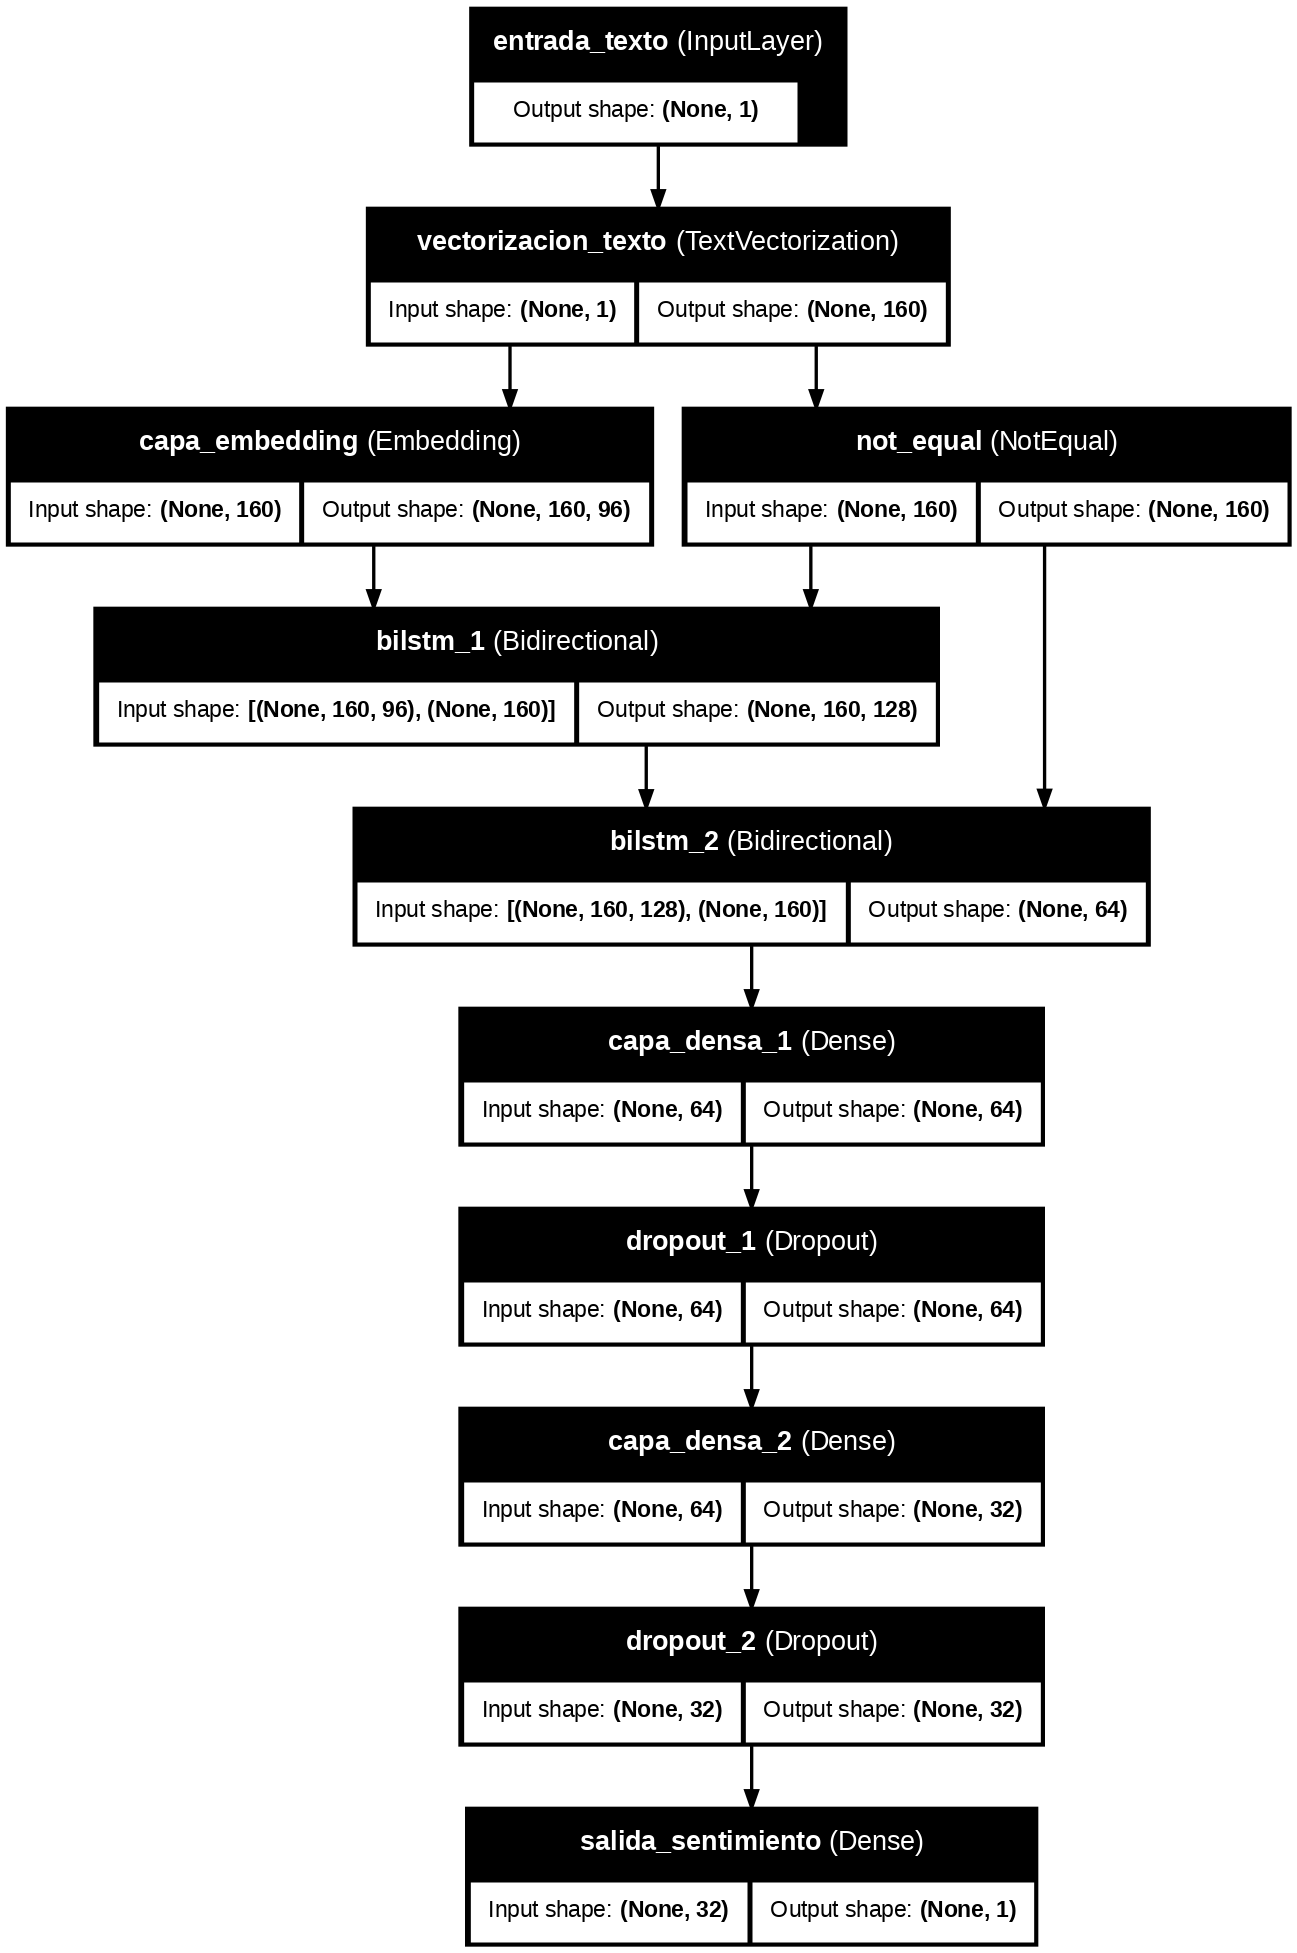

In [ ]:
plot_model(
    model,
    to_file="modelo_recurrente_imdb.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=120
)

display(Image("modelo_recurrente_imdb.png"))

## 17. Entrenamiento del modelo

El modelo se entrena con 10 épocas. El `EarlyStopping` se deja con paciencia 4 para darle más margen de aprendizaje, aunque detendrá el entrenamiento si la pérdida de validación deja de mejorar.

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    mode="max",
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=1,
    mode="max",
    min_lr=1e-5
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 704s 3s/step - accuracy: 0.7259 - loss: 0.5183 - precision: 0.7542 - recall: 0.6721 - val_accuracy: 0.8238 - val_loss: 0.3872 - val_precision: 0.8897 - val_recall: 0.7401 - learning_rate: 0.0010
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 751s 3s/step - accuracy: 0.8852 - loss: 0.2978 - precision: 0.8835 - recall: 0.8880 - val_accuracy: 0.8436 - val_loss: 0.3668 - val_precision: 0.8855 - val_recall: 0.7900 - learning_rate: 0.0010
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 676s 3s/step - accuracy: 0.9081 - loss: 0.2391 - precision: 0.9073 - recall: 0.9095 - val_accuracy: 0.8441 - val_loss: 0.3836 - val_precision: 0.8763 - val_recall: 0.8021 - learning_rate: 0.0010
Epoch 4/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 675s 3s/step - accuracy: 0.9345 - loss: 0.1801 - precision: 0.9330 - recall: 0.9365 - val_accuracy: 0.8395 - val_loss: 0.4241 - val_precision: 0.8934 - val_recall: 0.7719 - learning_rate: 0.0010
Epoch 5/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 678s 3s/step - accur

## 18. Curvas de entrenamiento

Las curvas permiten observar aprendizaje, estabilidad y posible sobreajuste.

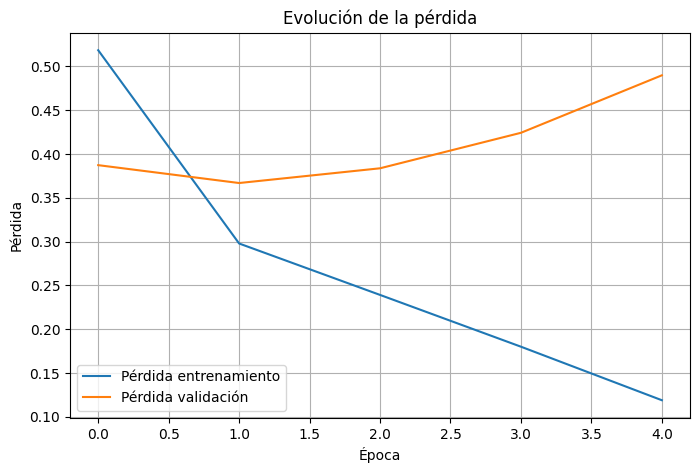

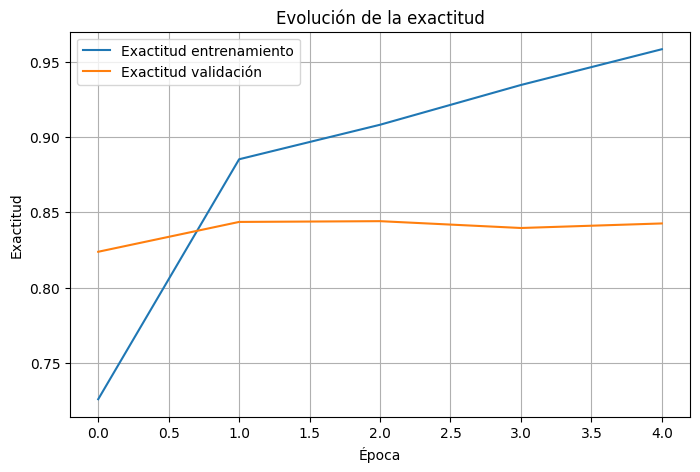

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Pérdida entrenamiento")
plt.plot(history_df["val_loss"], label="Pérdida validación")
plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Exactitud entrenamiento")
plt.plot(history_df["val_accuracy"], label="Exactitud validación")
plt.title("Evolución de la exactitud")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.legend()
plt.grid(True)
plt.show()

## 19. Evaluación del modelo en prueba

Se evalúa el modelo con datos no vistos. Esta es la medida más relevante para juzgar su capacidad de generalización.

In [ ]:
test_results = model.evaluate(test_ds, return_dict=True)

print("Resultados en prueba:")
for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 514ms/step - accuracy: 0.8406 - loss: 0.3853 - precision: 0.8683 - recall: 0.8038
Resultados en prueba:
accuracy: 0.8406
loss: 0.3853
precision: 0.8683
recall: 0.8038


## 20. Métricas finales: precision, recall y F1-score

Se calculan métricas detalladas para cada clase.

In [ ]:
y_prob = model.predict(tf.constant(X_test), batch_size=BATCH_SIZE, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negativa", "Positiva"],
    digits=4
))

summary_metrics = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

summary_metrics

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 550ms/step
              precision    recall  f1-score   support

    Negativa     0.8166    0.8776    0.8460      2973
    Positiva     0.8683    0.8038    0.8348      2986

    accuracy                         0.8406      5959
   macro avg     0.8424    0.8407    0.8404      5959
weighted avg     0.8425    0.8406    0.8404      5959



,Métrica,Valor
0,Accuracy,0.840577
1,Precision,0.868307
2,Recall,0.803751
3,F1-score,0.834783


## 21. Matriz de confusión

La matriz muestra aciertos y errores por clase.

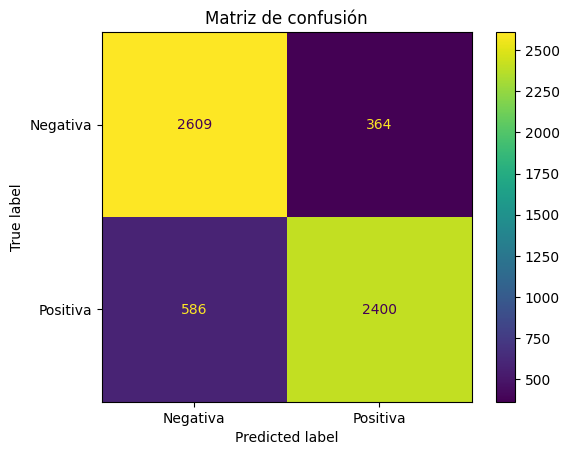

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativa", "Positiva"]
)

disp.plot(values_format="d")
plt.title("Matriz de confusión")
plt.show()

## 22. Clasificación de reseñas aleatorias del dataset

Se toman reseñas al azar y se compara la etiqueta real con la predicción del modelo.

In [ ]:
def predict_sentiment(review):
    """
    Recibe una reseña en texto y devuelve la probabilidad de sentimiento positivo.
    """
    review_clean = clean_text(review)
    review_tensor = tf.constant([review_clean])
    probability = model.predict(review_tensor, verbose=0)[0][0]
    label = "Positiva" if probability >= 0.5 else "Negativa"

    return {
        "reseña_limpia": review_clean,
        "probabilidad_positiva": float(probability),
        "clasificacion": label
    }

sample_df = df.sample(10, random_state=SEED).copy()

results = []
for _, row in sample_df.iterrows():
    result = predict_sentiment(row["text"])
    results.append({
        "reseña": row["text"][:250] + "...",
        "etiqueta_real": "Positiva" if row["label"] == 1 else "Negativa",
        "prediccion": result["clasificacion"],
        "probabilidad_positiva": result["probabilidad_positiva"]
    })

random_predictions_df = pd.DataFrame(results)
random_predictions_df

,reseña,etiqueta_real,prediccion,probabilidad_positiva
0,There are similarities between Ray Lawrence's ...,Negativa,Negativa,0.227995
1,Hammer House of Horror: Witching Time is set i...,Positiva,Positiva,0.892042
2,What a great cast for this movie. The timing w...,Positiva,Positiva,0.987625
3,I have never read the Bradbury novel that this...,Negativa,Negativa,0.099956
4,"This was a very enjoyable film. A humorous, bu...",Positiva,Positiva,0.998104
5,"I wouldn't call it awful, but nothing at all s...",Negativa,Negativa,0.001986
6,I bought my first Zep album in 1974 (at 17) an...,Positiva,Positiva,0.991754
7,STAR RATING: ***** Saturday Night **** Friday ...,Negativa,Positiva,0.513049
8,The movie and acting are not bad and Jay Herna...,Negativa,Negativa,0.010340
9,Rose and the good Doctor find themselves in a ...,Positiva,Positiva,0.930788


## 23. Extracción de la matriz de embeddings aprendida

La capa de embeddings contiene un vector para cada palabra del vocabulario.

In [ ]:
embedding_layer = model.get_layer("capa_embedding")
embedding_matrix = embedding_layer.get_weights()[0]

print("Forma de la matriz de embeddings:", embedding_matrix.shape)

Forma de la matriz de embeddings: (15000, 96)


## 24. Tabla de embeddings por palabra

Cada fila representa una palabra y cada columna una dimensión de su vector aprendido.

In [ ]:
embedding_df = pd.DataFrame(
    embedding_matrix,
    columns=[f"dim_{i}" for i in range(EMBEDDING_DIM)]
)

embedding_df.insert(0, "word", vocabulary)

embedding_df.head(20)

,word,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_86,dim_87,dim_88,dim_89,dim_90,dim_91,dim_92,dim_93,dim_94,dim_95
0,,0.035819,0.016263,-0.014129,0.044999,-0.042194,0.015233,0.047050,-0.033209,0.002379,...,0.036345,0.033789,0.012560,0.003613,0.004525,0.021434,-0.001840,-0.036903,0.039969,-0.013079
1,[UNK],0.056826,-0.000425,-0.028576,-0.036989,0.020353,0.007579,-0.050447,0.002465,-0.003069,...,-0.019761,-0.039945,-0.045284,-0.030133,-0.023601,-0.015717,0.025762,-0.052875,0.014229,-0.035830
2,the,-0.056914,-0.047986,0.008443,0.026423,-0.011589,0.030804,0.027541,0.014677,0.010439,...,0.036877,0.022882,-0.011429,0.004808,0.008699,0.011586,-0.024034,0.016426,-0.006254,0.028645
3,and,-0.007698,-0.037078,0.002295,0.023439,-0.009357,0.007726,0.082575,-0.019882,0.036335,...,0.018649,-0.013392,0.003075,-0.009783,0.007772,0.035647,-0.087880,-0.011100,-0.032400,0.031918
4,a,-0.004785,0.002052,0.001628,-0.022407,0.041990,0.021102,-0.027581,0.000865,-0.014219,...,0.010202,0.027028,0.023476,-0.046860,-0.032138,0.036854,0.020624,-0.057833,0.019129,-0.008892
5,of,-0.081102,0.020832,-0.060765,0.038155,-0.010163,0.064734,0.041403,0.032965,-0.038824,...,-0.010250,-0.028524,-0.046148,-0.033623,-0.042708,0.041834,0.013261,0.004236,0.006880,-0.026467
6,to,-0.016082,-0.057860,-0.037704,-0.036201,0.026320,0.009517,-0.010231,-0.009931,-0.025724,...,-0.013816,-0.043674,-0.007612,-0.026097,0.017116,-0.012387,-0.034639,-0.023439,-0.008027,0.013150
7,is,-0.009513,-0.026025,0.018045,0.031984,-0.015296,-0.004315,0.013411,-0.027856,-0.033946,...,0.039085,0.079818,0.061016,0.015806,0.030386,0.022529,-0.009128,0.011518,-0.003071,-0.017329
8,in,0.019192,-0.000604,-0.015834,0.042755,0.033067,-0.004078,-0.024056,-0.016474,-0.000096,...,-0.023507,-0.003048,0.004253,0.012857,-0.003858,-0.024043,-0.008222,-0.026348,-0.009252,0.041345
9,it,-0.074567,-0.033276,-0.025655,-0.036763,0.020435,0.056500,0.019077,-0.045141,0.085451,...,0.012555,-0.071425,-0.041158,0.013513,-0.003174,-0.014142,0.007954,0.034867,-0.008293,0.040777


## 25. Embeddings de palabras frecuentes

Se observan algunas palabras frecuentes del vocabulario y sus representaciones vectoriales.

In [ ]:
selected_words = vocabulary[2:52]
selected_embeddings = embedding_df[embedding_df["word"].isin(selected_words)]
selected_embeddings.head(10)

,word,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_86,dim_87,dim_88,dim_89,dim_90,dim_91,dim_92,dim_93,dim_94,dim_95
2,the,-0.056914,-0.047986,0.008443,0.026423,-0.011589,0.030804,0.027541,0.014677,0.010439,...,0.036877,0.022882,-0.011429,0.004808,0.008699,0.011586,-0.024034,0.016426,-0.006254,0.028645
3,and,-0.007698,-0.037078,0.002295,0.023439,-0.009357,0.007726,0.082575,-0.019882,0.036335,...,0.018649,-0.013392,0.003075,-0.009783,0.007772,0.035647,-0.087880,-0.011100,-0.032400,0.031918
4,a,-0.004785,0.002052,0.001628,-0.022407,0.041990,0.021102,-0.027581,0.000865,-0.014219,...,0.010202,0.027028,0.023476,-0.046860,-0.032138,0.036854,0.020624,-0.057833,0.019129,-0.008892
5,of,-0.081102,0.020832,-0.060765,0.038155,-0.010163,0.064734,0.041403,0.032965,-0.038824,...,-0.010250,-0.028524,-0.046148,-0.033623,-0.042708,0.041834,0.013261,0.004236,0.006880,-0.026467
6,to,-0.016082,-0.057860,-0.037704,-0.036201,0.026320,0.009517,-0.010231,-0.009931,-0.025724,...,-0.013816,-0.043674,-0.007612,-0.026097,0.017116,-0.012387,-0.034639,-0.023439,-0.008027,0.013150
7,is,-0.009513,-0.026025,0.018045,0.031984,-0.015296,-0.004315,0.013411,-0.027856,-0.033946,...,0.039085,0.079818,0.061016,0.015806,0.030386,0.022529,-0.009128,0.011518,-0.003071,-0.017329
8,in,0.019192,-0.000604,-0.015834,0.042755,0.033067,-0.004078,-0.024056,-0.016474,-0.000096,...,-0.023507,-0.003048,0.004253,0.012857,-0.003858,-0.024043,-0.008222,-0.026348,-0.009252,0.041345
9,it,-0.074567,-0.033276,-0.025655,-0.036763,0.020435,0.056500,0.019077,-0.045141,0.085451,...,0.012555,-0.071425,-0.041158,0.013513,-0.003174,-0.014142,0.007954,0.034867,-0.008293,0.040777
10,i,-0.000449,-0.025538,-0.044363,-0.003905,-0.007906,0.008487,0.007680,0.019906,0.021899,...,0.048079,-0.017690,-0.066784,0.009149,-0.042596,0.004028,-0.012050,0.009309,0.030696,-0.027235
11,this,0.016089,0.055092,0.033762,-0.029105,0.035707,0.008774,0.062718,-0.059715,0.007430,...,0.026721,0.053695,0.043239,0.025283,-0.019085,0.049062,-0.025443,0.033557,-0.024911,-0.029560


## 26. UMAP 3D coloreado según clasificación positiva o negativa

En lugar de graficar solo palabras, esta visualización representa reseñas completas. Para cada reseña se calcula un vector promedio de sus embeddings. Luego UMAP reduce esos vectores a 3 dimensiones y el gráfico se colorea según la clasificación predicha por el modelo. Esto permite ver, aunque con limitaciones claras, si el espacio aprendido tiende a separar reseñas positivas y negativas.

In [ ]:
# Número de reseñas a visualizar. Se mantiene moderado para que UMAP sea rápido.
N_REVIEWS_UMAP = min(1200, len(X_test))

rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_test), size=N_REVIEWS_UMAP, replace=False)

X_umap_text = X_test[sample_indices]
y_umap_real = y_test[sample_indices]

# Vectorización de reseñas seleccionadas
sequences_umap = vectorizer(tf.constant(X_umap_text)).numpy()

# Promedio de embeddings por reseña, ignorando el padding 0
review_vectors = []
for sequence in sequences_umap:
    token_ids = sequence[sequence != 0]
    if len(token_ids) == 0:
        review_vectors.append(np.zeros(EMBEDDING_DIM))
    else:
        review_vectors.append(embedding_matrix[token_ids].mean(axis=0))

review_vectors = np.array(review_vectors)

# Predicción del modelo sobre esas reseñas
y_umap_prob = model.predict(tf.constant(X_umap_text), batch_size=BATCH_SIZE, verbose=0).ravel()
y_umap_pred = (y_umap_prob >= 0.5).astype(int)

# Reducción UMAP a 3 dimensiones
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=20,
    min_dist=0.10,
    metric="cosine",
    random_state=SEED
)

review_embedding_3d = umap_model.fit_transform(review_vectors)

umap_reviews_df = pd.DataFrame({
    "x": review_embedding_3d[:, 0],
    "y": review_embedding_3d[:, 1],
    "z": review_embedding_3d[:, 2],
    "texto": [text[:220] + "..." for text in X_umap_text],
    "etiqueta_real": np.where(y_umap_real == 1, "Positiva", "Negativa"),
    "clasificacion_modelo": np.where(y_umap_pred == 1, "Positiva", "Negativa"),
    "probabilidad_positiva": y_umap_prob
})

umap_reviews_df.head()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,x,y,z,texto,etiqueta_real,clasificacion_modelo,probabilidad_positiva
0,-0.472777,7.196725,7.718020,lisa is a hotel manager or owner and she gets ...,Positiva,Positiva,0.711014
1,-1.472633,6.188356,7.620130,based on its current imdb rating as well as se...,Positiva,Positiva,0.910654
2,1.907144,7.795653,7.163858,die sieger was highly recommended to be one of...,Negativa,Negativa,0.203799
3,-0.095287,7.379870,7.097411,this show is my guilty pleasure all the way wh...,Positiva,Positiva,0.914136
4,0.736528,6.587648,6.107597,i saw this hot movie when it came out in it ha...,Negativa,Positiva,0.702250


## 27. Gráfico UMAP 3D interactivo

El color corresponde a la clasificación del modelo. Al pasar el cursor por cada punto se observa una parte de la reseña, su etiqueta real, la predicción y la probabilidad estimada.

In [ ]:
fig = px.scatter_3d(
    umap_reviews_df,
    x="x",
    y="y",
    z="z",
    color="clasificacion_modelo",
    hover_data={
        "texto": True,
        "etiqueta_real": True,
        "clasificacion_modelo": True,
        "probabilidad_positiva": ":.4f",
        "x": False,
        "y": False,
        "z": False
    },
    title="UMAP 3D de reseñas según clasificación del modelo"
)

fig.update_traces(marker=dict(size=4, opacity=0.75))
fig.show()

## 28. UMAP 3D de palabras con orientación de sentimiento

Esta segunda visualización trabaja sobre palabras. Se calcula una orientación aproximada de sentimiento usando la similitud entre cada palabra y términos semilla positivos y negativos. No equivale a una etiqueta definitiva, pero ayuda a leer el espacio de embeddings.

In [ ]:
positive_seed_words = ["good", "great", "excellent", "amazing", "best", "love", "wonderful"]
negative_seed_words = ["bad", "terrible", "awful", "worst", "boring", "poor", "hate"]

word_to_index = {word: idx for idx, word in enumerate(vocabulary)}

def get_seed_vector(seed_words):
    valid_indices = [word_to_index[word] for word in seed_words if word in word_to_index]
    if len(valid_indices) == 0:
        return np.zeros(EMBEDDING_DIM)
    return embedding_matrix[valid_indices].mean(axis=0)

positive_vector = get_seed_vector(positive_seed_words)
negative_vector = get_seed_vector(negative_seed_words)

N_WORDS = min(1000, len(vocabulary) - 2)
words_plot = vocabulary[2:N_WORDS + 2]
vectors_plot = embedding_matrix[2:N_WORDS + 2]

def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0
    return float(np.dot(a, b) / denom)

sentiment_orientation = []
for vector in vectors_plot:
    pos_sim = cosine_similarity(vector, positive_vector)
    neg_sim = cosine_similarity(vector, negative_vector)
    sentiment_orientation.append("Más positiva" if pos_sim >= neg_sim else "Más negativa")

word_umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)

word_embedding_3d = word_umap_model.fit_transform(vectors_plot)

umap_words_df = pd.DataFrame({
    "word": words_plot,
    "x": word_embedding_3d[:, 0],
    "y": word_embedding_3d[:, 1],
    "z": word_embedding_3d[:, 2],
    "orientacion": sentiment_orientation
})

umap_words_df.head()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



,word,x,y,z,orientacion
0,the,6.772495,7.027236,0.432084,Más positiva
1,and,7.832664,6.337758,0.174784,Más negativa
2,a,7.217251,6.863200,0.628792,Más negativa
3,of,7.238034,7.506706,0.022602,Más positiva
4,to,5.886011,3.849814,4.122418,Más negativa


## 29. Gráfico UMAP 3D de palabras

El gráfico colorea las palabras según una orientación aproximada hacia términos positivos o negativos.

In [ ]:
fig = px.scatter_3d(
    umap_words_df,
    x="x",
    y="y",
    z="z",
    color="orientacion",
    hover_name="word",
    title="UMAP 3D de palabras según orientación aproximada de sentimiento"
)

fig.update_traces(marker=dict(size=4, opacity=0.75))
fig.show()

## 30. Guardado del modelo entrenado

Se guarda el modelo completo para reutilizarlo posteriormente.

In [ ]:
model.save("modelo_recurrente_imdb_sentiment.keras")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.


## 31. Justificación breve de la arquitectura

La capa de vectorización transforma cada reseña en una secuencia numérica de longitud fija. Luego, la capa de embeddings aprende una representación densa para cada término del vocabulario, lo cual permite que palabras usadas en contextos similares adopten posiciones relativamente cercanas en el espacio vectorial. La capa recurrente bidireccional procesa la reseña en ambos sentidos y captura dependencias contextuales. En este notebook se utiliza GRU para acelerar la ejecución, aunque conserva el principio recurrente solicitado para análisis secuencial. La capa densa integra la información extraída antes de la salida, y la activación sigmoide entrega una probabilidad de pertenencia a la clase positiva.